<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py1836h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Function Estimation

#### We'll try to estimate the quality of red wine samples based on their physical and chemical features
#### We compute and report the mean absolute error, MAE

In [ ]:
# CNN version
# Regression Example With wine dataset ...
import pandas as pd
from pandas import read_csv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# mounting the Google drive
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
fp = "/content/drive/My Drive/Emeritus/Wi20260423/Module3-3/wine_r2_t_noheader.csv"




Mounted at /content/drive


In [ ]:

# load dataset to a Pandas dataframe
dataframe = read_csv(fp , header=None)
# copy only values to a numpy n dimensional array, ndarray
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:11]
Y = dataset[:,11]

print(X.shape)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)


(1599, 11)
(1599, 11, 1)


In [ ]:
print(type(dataset))
print(dataset.shape)
print(dataframe.describe())
print( dataframe.head() )

<class 'numpy.ndarray'>
(1599, 12)
                0            1            2            3            4   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean      8.319637     0.527821     0.270976     2.538806     0.087467   
std       1.741096     0.179060     0.194801     1.409928     0.047065   
min       4.600000     0.120000     0.000000     0.900000     0.012000   
25%       7.100000     0.390000     0.090000     1.900000     0.070000   
50%       7.900000     0.520000     0.260000     2.200000     0.079000   
75%       9.200000     0.640000     0.420000     2.600000     0.090000   
max      15.900000     1.580000     1.000000    15.500000     0.611000   

                5            6            7            8            9   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean     15.874922    46.467792     0.996747     3.311113     0.658149   
std      10.460157    32.895324     0.001887     0.154386     0.169507   
mi

In [ ]:
# define base model, a deep covolutional one
# structure comprisses 2 1d convolution layers with 16 and 12 filters, filters are 3x1
# then maxpooling for downsampling, a fully connected dense layer with 12 neurons
# Droput layer with 20% at the end
#
def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, input_dim=8, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model


In [ ]:
# splitting the train and test subsets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
# training the model for 900 epochs and testing the trained model with the training data
# we report the training error
estimator = baseline_model()
estimator.fit(X_train, Y_train, epochs=900, verbose=2)
prediction = estimator.predict(X_train)

train_error =  np.abs(Y_train - prediction)
mean_error = np.mean(train_error)
min_error = np.min(train_error)
max_error = np.max(train_error)
std_error = np.std(train_error)
print('\nTraining results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/900


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 - 5s - 136ms/step - loss: 22.8733
Epoch 2/900
40/40 - 0s - 4ms/step - loss: 11.1256
Epoch 3/900
40/40 - 0s - 3ms/step - loss: 9.4151
Epoch 4/900
40/40 - 0s - 3ms/step - loss: 8.1242
Epoch 5/900
40/40 - 0s - 3ms/step - loss: 5.3059
Epoch 6/900
40/40 - 0s - 3ms/step - loss: 3.0026
Epoch 7/900
40/40 - 0s - 3ms/step - loss: 2.6430
Epoch 8/900
40/40 - 0s - 3ms/step - loss: 2.6032
Epoch 9/900
40/40 - 0s - 4ms/step - loss: 2.5278
Epoch 10/900
40/40 - 0s - 7ms/step - loss: 2.3978
Epoch 11/900
40/40 - 0s - 3ms/step - loss: 2.3091
Epoch 12/900
40/40 - 0s - 3ms/step - loss: 2.4267
Epoch 13/900
40/40 - 0s - 3ms/step - loss: 2.3095
Epoch 14/900
40/40 - 0s - 3ms/step - loss: 2.5389
Epoch 15/900
40/40 - 0s - 3ms/step - loss: 2.4747
Epoch 16/900
40/40 - 0s - 3ms/step - loss: 2.2542
Epoch 17/900
40/40 - 0s - 3ms/step - loss: 2.2652
Epoch 18/900
40/40 - 0s - 3ms/step - loss: 2.4039
Epoch 19/900
40/40 - 0s - 3ms/step - loss: 2.1835
Epoch 20/900
40/40 - 0s - 5ms/step - loss: 2.1757
Epoch 21/900
40/4

In [ ]:
# showing the real and predicted quality scores for the training data
df = pd.DataFrame({'Actual': Y_train, 'Predicted': prediction.ravel() })
df1 = df.tail(25)
print(df1)

      Actual  Predicted
1254     6.0   5.571921
1255     6.0   5.157120
1256     5.0   5.157120
1257     5.0   5.409508
1258     6.0   5.471840
1259     5.0   5.318044
1260     5.0   5.287631
1261     5.0   5.543654
1262     6.0   6.059115
1263     6.0   6.392192
1264     5.0   5.157120
1265     5.0   5.654971
1266     5.0   5.157120
1267     4.0   5.157120
1268     5.0   5.157120
1269     6.0   5.421474
1270     6.0   6.026847
1271     6.0   6.172830
1272     6.0   5.656199
1273     5.0   5.157120
1274     5.0   5.157120
1275     5.0   5.157120
1276     6.0   5.383024
1277     6.0   5.740448
1278     5.0   5.157120


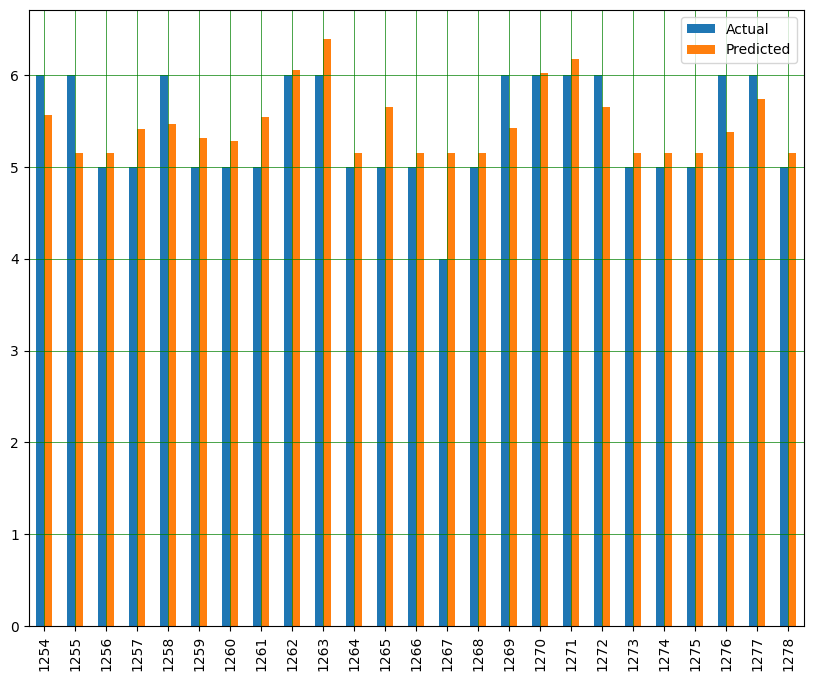

In [ ]:
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

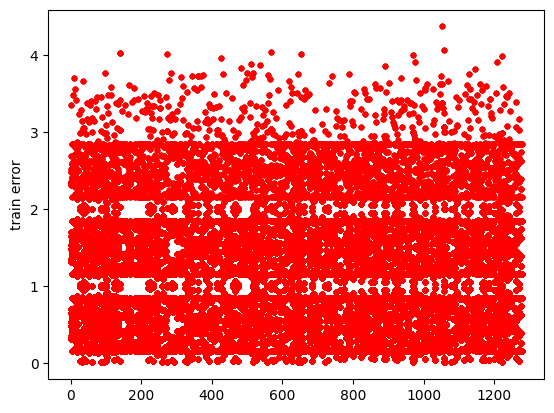

In [ ]:
plt.plot(train_error,'r.')
plt.ylabel('train error')
plt.show()

In [ ]:
# testing the model with the test data
prediction = estimator.predict(X_test)

test_error =  np.abs(Y_test - prediction)
mean_error = np.mean(test_error)
min_error = np.min(test_error)
max_error = np.max(test_error)
std_error = np.std(test_error)
print('\nTesting results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Testing results:
mean= 0.7194093792699278 
min= 0.017434120178222656 
max= 3.9246068000793457 
std= 0.533644160725703


In [ ]:
# and showing the results
df = pd.DataFrame({'Actual': Y_test, 'Predicted': prediction.ravel() })
df1 = df.tail(25)
print(df1)

     Actual  Predicted
295     6.0   5.705862
296     6.0   5.469358
297     5.0   5.507373
298     6.0   5.219898
299     5.0   5.268188
300     6.0   5.484595
301     5.0   5.157120
302     6.0   5.426975
303     6.0   5.659230
304     6.0   5.547380
305     6.0   5.925727
306     5.0   5.172128
307     5.0   5.175369
308     6.0   5.897129
309     5.0   5.524915
310     5.0   5.449653
311     6.0   6.329712
312     5.0   5.538383
313     5.0   5.157120
314     5.0   5.333896
315     6.0   5.548357
316     4.0   6.078797
317     5.0   5.639140
318     4.0   5.157120
319     6.0   5.763243


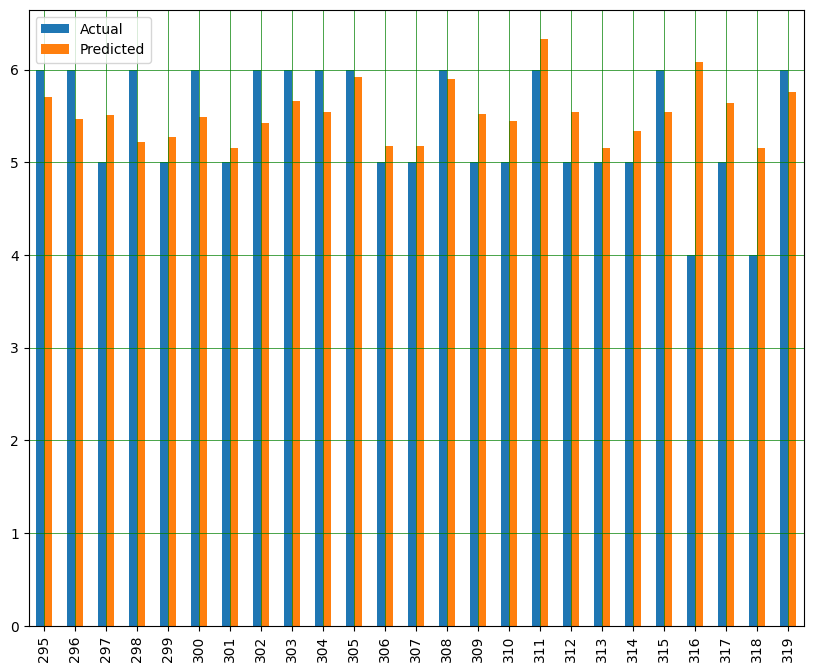

In [ ]:
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

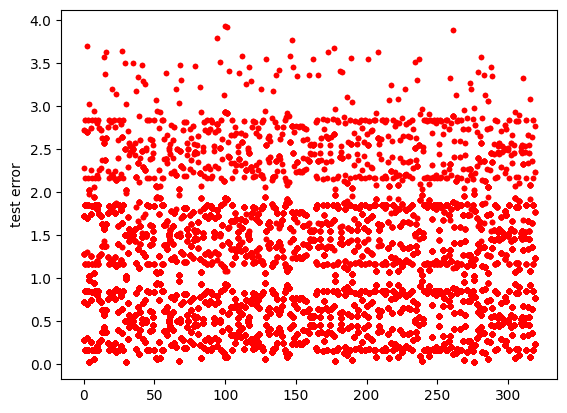

In [ ]:
plt.plot(test_error,'r.')
plt.ylabel('test error')
plt.show()

##  Practices
1. train the model for 1400 epochs. what are the training and testing MAE?
2. repeat that with 6000 training epochs. what are the training and testing MAE?
3. move back to 900 training epochs. add two convolutional and one dense layer with the same features of the layers used. what are the training and testing MAE?
4. go for 6000 training epochs. Do you feel any overfitting?
5. set back everything to the original setting, then try to normalize the training and testing features and outputs using standard_scaler. Then see if anything gets better or not. You may use insttructions like what you can see in the next cell.  

#### points:
- use GPU as your runtime type
- if the notebook overflows, change the verbose to 0, e.g. verbose=0 in the training cell.

In [ ]:
'''
# normalization
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize X_train and X_test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)
y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed
y_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))
'''

'\n# normalization\nfrom sklearn.preprocessing import StandardScaler\n\n# Create scalers\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\n\n# Standardize X_train and X_test\nX_train_scaled = scaler_X.fit_transform(X_train)\nX_test_scaled = scaler_X.transform(X_test)\n\n# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)\ny_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed\ny_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))\n'